In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape
import joblib

<h2>Lectura y Tratamiento de Datos</h2>

In [4]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, ['PERD', 'QGEN7']]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS ENTRADA
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

**Validación por Retención (Tratamiento como Serie Temporal)**

In [5]:
# VALIDACIÓN POR RETENCIÓN PARA EVALUACIÓN FINAL DEL MEJOR MODELO
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

<h2>Búsqueda Aleatoria de Hiperparámetros</h2>

In [6]:
random_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(3, 9),
    'estimator1__learning_rate': uniform(0.01, 0.2),
    'estimator1__colsample_bytree': uniform(0.4, 0.5),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(4, 11),
    'estimator2__learning_rate': uniform(0.01, 0.2),
    'estimator2__colsample_bytree': uniform(0.4, 0.5)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [7]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"ElectricSeque...ee=None, ...))"
,param_distributions,"{'estimator1__colsample_bytree': <scipy.stats....0025291CE09D0>, 'estimator1__learning_rate': <scipy.stats....0025291CE0250>, 'estimator1__max_depth': <scipy.stats....0025291CD4E50>, 'estimator1__n_estimators': <scipy.stats....0025291C69690>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


<h2>Evaluación del Mejor Modelo Aleatorio</h2>

In [8]:
# PREDICCIONES DEL MEJOR MODELO CON VALORES DEL "FUTURO" X_TEST, YA QUE LO TRATAMOS COMO SERIE TEMPORAL
best_random_model = random_search.best_estimator_
random_predictions = best_random_model.predict(x_test)
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.07436466092864673


,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,-0.133830,-0.267346,-0.000315
1,-0.125523,-0.250707,-0.000341
2,-0.137357,-0.274377,-0.000338
3,-0.089301,-0.177465,-0.001137
4,-0.077885,-0.155456,-0.000314
5,-0.101954,-0.203578,-0.000332
6,-0.118726,-0.237137,-0.000314
7,-0.151275,-0.302231,-0.000320
8,-0.087527,-0.174744,-0.000312
9,-0.179874,-0.359443,-0.000307


In [7]:
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
random_MAPE = mean_absolute_percentage_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE_shifted = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')

In [8]:
# RESULTADOS CON MAPE DESPLAZADO
random_data_score_shifted = np.vstack([random_MAE, random_MAPE_shifted, random_R2])
evaluations_shifted = pd.DataFrame(random_data_score_shifted, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])
evaluations_shifted

,PERD,QGEN7
MAE,0.236427,0.016979
MAPE,0.026941,0.015958
R2,0.977467,0.796058


In [9]:
# RESULTADOS SIN DESPLAZAMIENTO
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])
evaluations

,PERD,QGEN7
MAE,0.236427,1.697937e-02
MAPE,0.031469,3.076511e+13
R2,0.977467,7.960582e-01


**Validación Cruzada para Contrastación de Resultados**

In [11]:
random_search.best_params_

{'estimator1__colsample_bytree': np.float64(0.4165253664502742),
 'estimator1__learning_rate': np.float64(0.0790142496053366),
 'estimator1__max_depth': 3,
 'estimator1__n_estimators': 48,
 'estimator2__colsample_bytree': np.float64(0.7403527257773834),
 'estimator2__learning_rate': np.float64(0.11618691666342727),
 'estimator2__max_depth': 5,
 'estimator2__n_estimators': 239}

In [12]:
evaluate_model_shifted = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.416, learning_rate=0.079, max_depth=3, n_estimators=48, n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', colsample_bytree=0.74, learning_rate=0.116, max_depth=5, n_estimators=239, n_jobs=1, random_state=42))
evaluate_scoring_shifted = { # EVALUACIÓN CON DESPLAZAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results_shifted = cross_validate(evaluate_model_shifted, X, Y, scoring=evaluate_scoring_shifted, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results_shifted['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results_shifted['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results_shifted['test_mape'].mean()))
print('R2: ' + str(evaluate_results_shifted['test_r2'].mean()))

MSE: 0.08933069780468941
MAE: 0.13368080258369447
MAPE: 0.022200898435725418
R2: 0.8922105193138122


In [13]:
evaluate_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.416, learning_rate=0.079, max_depth=3, n_estimators=48, n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', colsample_bytree=0.74, learning_rate=0.116, max_depth=5, n_estimators=239, n_jobs=1, random_state=42))
evaluate_scoring = { # EVALUACIÓN SIN DESPLAMIENTO EN MAPE
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.08933069780468941
MAE: 0.13368080258369447
MAPE: 15225802090086.4
R2: 0.8922105193138122


<h2>Figuras de Rendimiento del Mejor Modelo</h2>

In [14]:
joblib.dump(best_random_model, '../models/ESR_XGBoost.pkl')

['../models/ESR_XGBoost.pkl']

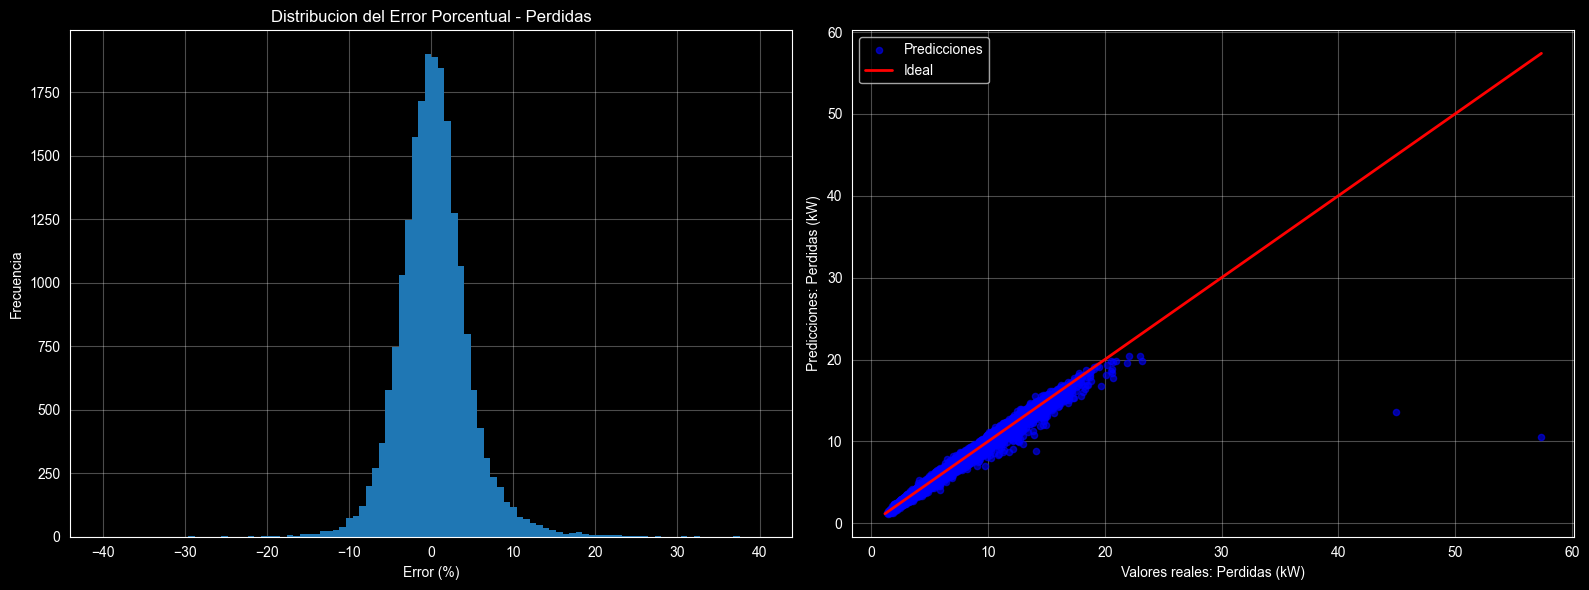

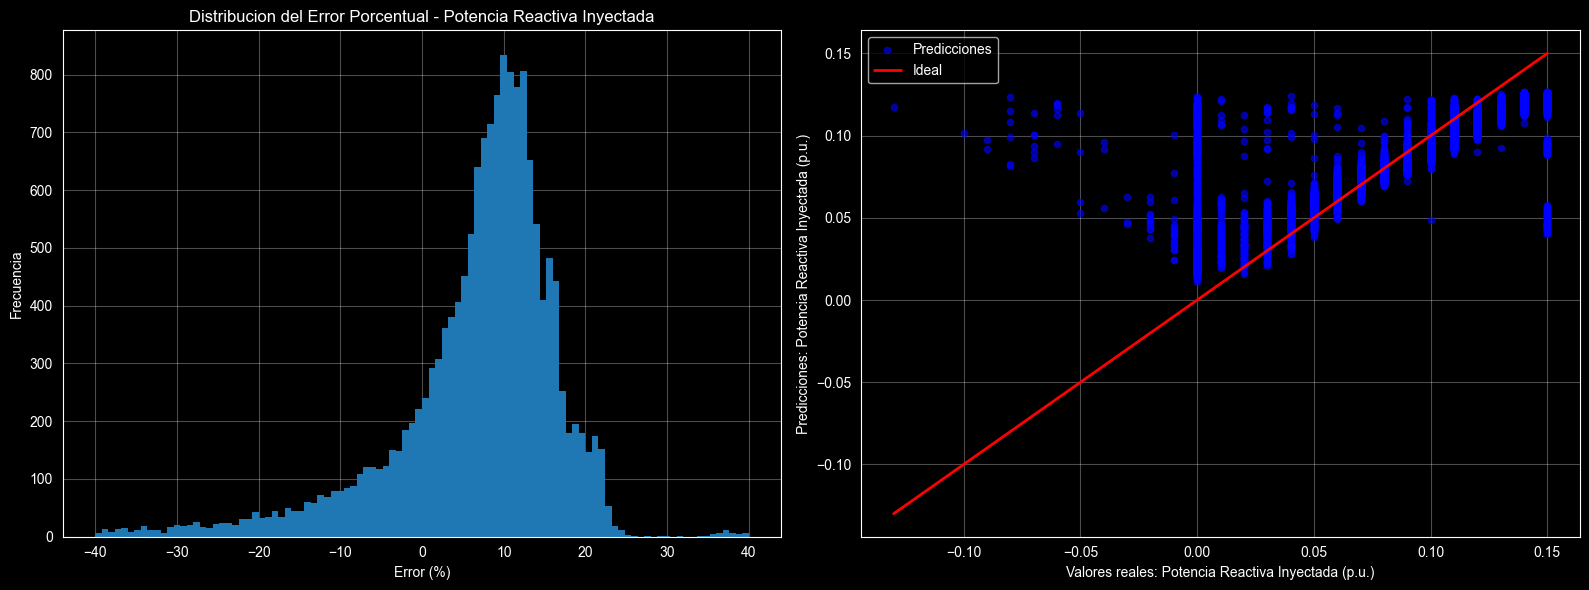

In [15]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/XGBoost/ESR_XGBoost_Perd.png'
)

plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/XGBoost/ESR_XGBoost_QGen.png'
)